In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

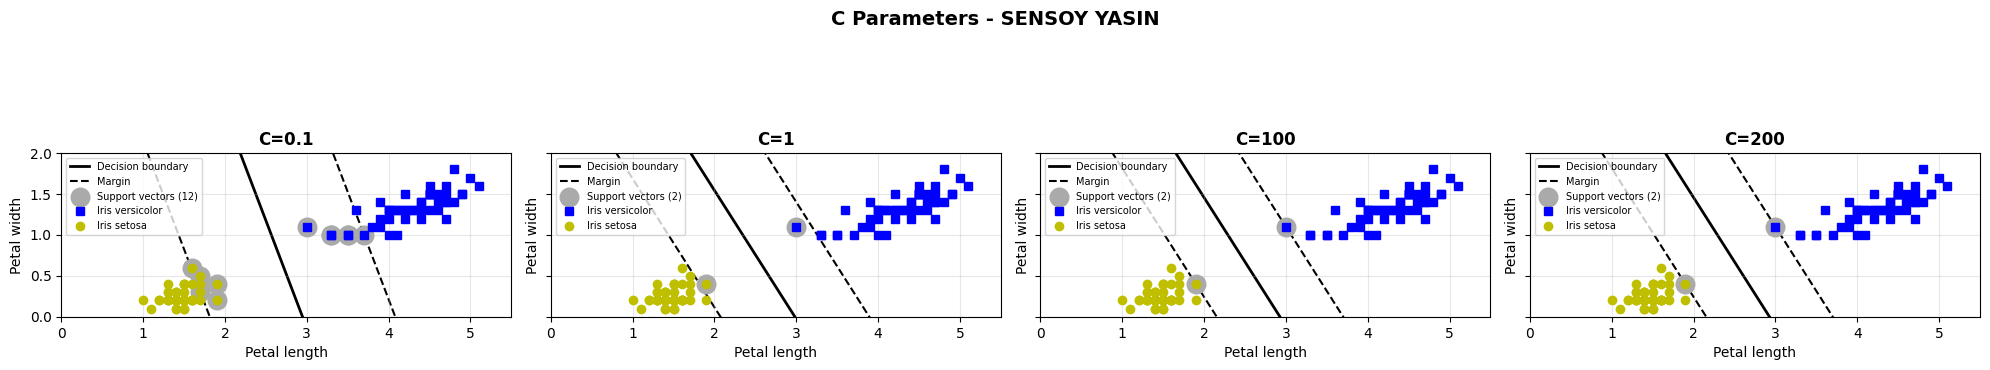

In [8]:
from sklearn.svm import SVC
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

iris = datasets.load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target
setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

def plot_svc_decision_boundary(svm_clf, xmin, xmax, ax, title):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
    x0 = np.linspace(xmin, xmax, 200)
    
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]
    margin = 1 / w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_
    ax.plot(x0, decision_boundary, "k-", linewidth=2, zorder=-2, label="Decision boundary")
    ax.plot(x0, gutter_up, "k--", linewidth=1.5, zorder=-2, label="Margin")
    ax.plot(x0, gutter_down, "k--", linewidth=1.5, zorder=-2)
    ax.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#AAA', zorder=-1, label=f"Support vectors ({len(svs)})")
    ax.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
    ax.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")
    ax.set_xlabel("Petal length")
    ax.set_ylabel("Petal width")
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis([0, 5.5, 0, 2])
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=7)

C_values = [0.1, 1, 100, 200]
labels = [
    "C=0.1",
    "C=1",
    "C=100",
    "C=200"
]

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
fig.suptitle("C Parameters - SENSOY YASIN", fontsize=14, fontweight='bold', y=1.02)

for ax, C, label in zip(axes, C_values, labels):
    model = SVC(kernel="linear", C=C)
    model.fit(X, y)
    plot_svc_decision_boundary(model, 0, 5.5, ax, label)

plt.tight_layout()
plt.show()

### Feature Scaling in SVM
Feature scaling is critical for SVM - more than almost any other algorithm.
SVM tries to maximize the margin between classes. The margin is calculated using distances between points.

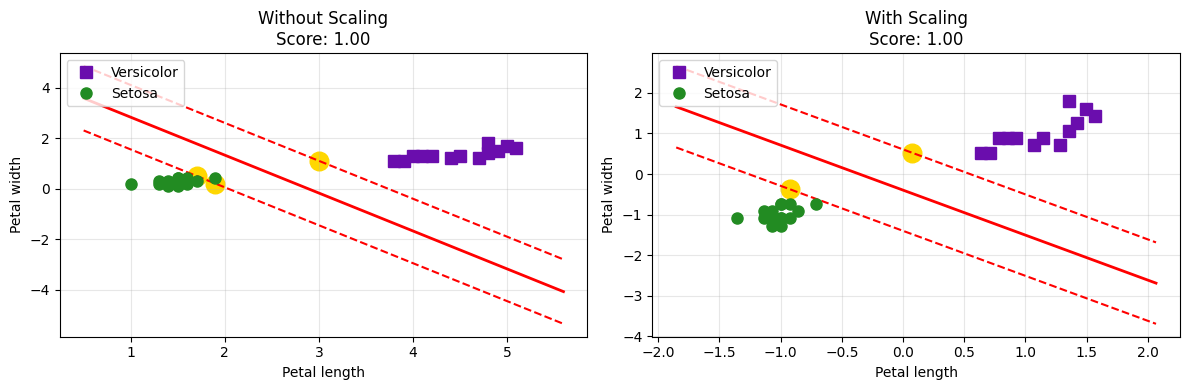

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

def plot_svc_decision_boundary(svm_clf, X, y, ax, title):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
    x0 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
    
    decision_boundary = -w[0] / w[1] * x0 - b / w[1]
    margin = 1 / w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    svs = svm_clf.support_vectors_

    ax.plot(x0, decision_boundary, "r-", linewidth=2)
    ax.plot(x0, gutter_up, "r--", linewidth=1.5)
    ax.plot(x0, gutter_down, "r--", linewidth=1.5)
    
    ax.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFD700', zorder=-1)
    ax.plot(X[:, 0][y==1], X[:, 1][y==1], "s", color="#6A0DAD", markersize=8, label="Versicolor") 
    ax.plot(X[:, 0][y==0], X[:, 1][y==0], "o", color="#228B22", markersize=8, label="Setosa")     
    ax.set_title(f"{title}\nScore: {svm_clf.score(X, y):.2f}")
    ax.set_xlabel("Petal length")
    ax.set_ylabel("Petal width")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

svm_no_scale = SVC(kernel="linear", C=5).fit(X_train, y_train)
svm_scaled   = SVC(kernel="linear", C=5).fit(scaled_X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_svc_decision_boundary(svm_no_scale, X_test,        y_test, axes[0], "Without Scaling")
plot_svc_decision_boundary(svm_scaled,   scaled_X_test, y_test, axes[1], "With Scaling")

plt.tight_layout()
plt.show()

Different dataset

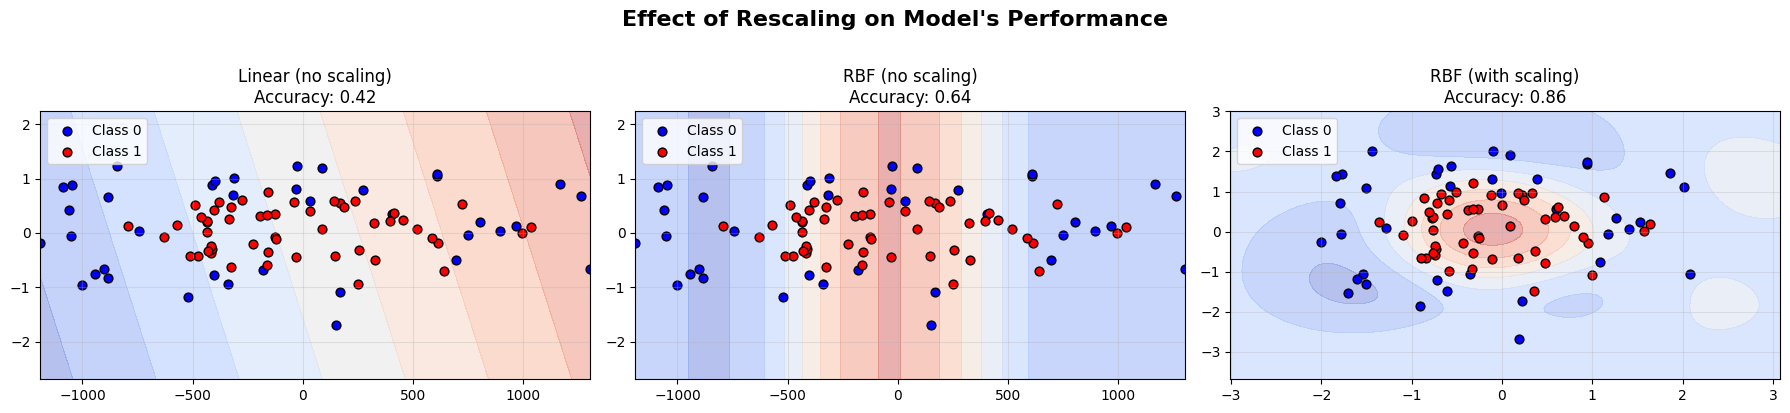

In [27]:
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay

X, y = make_circles(n_samples=300, noise=0.30, factor=0.4, random_state=42)
X[:, 0] = X[:, 0] * 1000 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test  = scaler.transform(X_test)

svm_linear     = SVC(kernel="linear", C=5).fit(X_train, y_train)
svm_rbf_noscale= SVC(kernel="rbf", C=5, max_iter=1000).fit(X_train, y_train)
svm_rbf        = SVC(kernel="rbf", C=5).fit(scaled_X_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Effect of Rescaling on Model's Performance", fontsize=16, fontweight="bold", y=1.02)

for ax, model, X_te, title in zip(
    axes,
    [svm_linear,              svm_rbf_noscale,          svm_rbf],
    [X_test,                  X_test,                   scaled_X_test],
    ["Linear (no scaling)",   "RBF (no scaling)",       "RBF (with scaling)"]
):
    DecisionBoundaryDisplay.from_estimator(model, X_te, alpha=0.4, ax=ax, cmap="coolwarm")
    ax.scatter(X_te[:, 0][y_test==0], X_te[:, 1][y_test==0], c="blue", edgecolors="k", s=40, label="Class 0")
    ax.scatter(X_te[:, 0][y_test==1], X_te[:, 1][y_test==1], c="red",  edgecolors="k", s=40, label="Class 1")
    
    ax.set_title(f"{title}\nAccuracy: {accuracy_score(y_test, model.predict(X_te)):.2f}", fontsize=12)
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Effect of rescaling on model’s performance
The results show 3 key insights:
1. Linear kernel always fails on non-linear data regardless of scaling — a straight line simply cannot separate circles.
2. RBF without scaling fails even though RBF is powerful — because the 1000x difference in feature scales makes the kernel blind to Feature 1 (it's too small compared to Feature 0).
3. RBF with scaling works — once both features are on equal scale, RBF can detect the circular pattern and separate the classes properly.
Bottom line: It's not enough to choose the right kernel — you also need to scale your data. The best model (RBF) completely fails without scaling, performing no better than random guessing.

In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, log_loss

for c in [0.1, 1, 5, 10, 50]:
    model = SVC(kernel="rbf", C=c, probability=True).fit(scaled_X_train, y_train)
    acc = accuracy_score(y_test, model.predict(scaled_X_test))
    ll  = log_loss(y_test, model.predict_proba(scaled_X_test))
    print(f"C={c:<4} → Accuracy: {acc:.2%}  Log-loss: {ll:.3f}")

param_grid = {'C': [0.1, 1, 5, 10, 50]}
grid = GridSearchCV(SVC(kernel="rbf", probability=True), param_grid, cv=5, scoring="accuracy")
grid.fit(scaled_X_train, y_train)

print("Best C:", grid.best_params_)
print("Best CV Score:", f"{grid.best_score_:.2%}")
print("Test Accuracy:", f"{accuracy_score(y_test, grid.predict(scaled_X_test)):.2%}")

C=0.1  → Accuracy: 87.78%  Log-loss: 0.350
C=1    → Accuracy: 87.78%  Log-loss: 0.369
C=5    → Accuracy: 85.56%  Log-loss: 0.377
C=10   → Accuracy: 85.56%  Log-loss: 0.397
C=50   → Accuracy: 84.44%  Log-loss: 0.434
Best C: {'C': 0.1}
Best CV Score: 79.52%
Test Accuracy: 87.78%


The results show a very clear pattern:

As C increases → Accuracy drops, Log-loss increases

noise=0.30 is quite high — data is already messy

Large C → tries to fit the noise too → overfitting

Small C → "tolerate some errors, learn the general pattern" → better generalization

In [30]:
for kernel in ["rbf", "poly", "sigmoid"]:
    for c in [0.1, 1, 5]:
        model = SVC(kernel=kernel, C=c, probability=True).fit(scaled_X_train, y_train)
        acc = accuracy_score(y_test, model.predict(scaled_X_test))
        ll  = log_loss(y_test, model.predict_proba(scaled_X_test))
        print(f"kernel={kernel:<8} C={c:<4} → Accuracy: {acc:.2%}  Log-loss: {ll:.3f}")
    print()

kernel=rbf      C=0.1  → Accuracy: 87.78%  Log-loss: 0.355
kernel=rbf      C=1    → Accuracy: 87.78%  Log-loss: 0.374
kernel=rbf      C=5    → Accuracy: 85.56%  Log-loss: 0.384

kernel=poly     C=0.1  → Accuracy: 42.22%  Log-loss: 0.700
kernel=poly     C=1    → Accuracy: 42.22%  Log-loss: 0.693
kernel=poly     C=5    → Accuracy: 42.22%  Log-loss: 0.691

kernel=sigmoid  C=0.1  → Accuracy: 42.22%  Log-loss: 0.707
kernel=sigmoid  C=1    → Accuracy: 61.11%  Log-loss: 0.706
kernel=sigmoid  C=5    → Accuracy: 57.78%  Log-loss: 0.698



RBF clearly wins for this dataset. Here's why:

RBF → 87.78% accuracy, lowest log-loss

Designed for circular/non-linear boundaries → perfect match for make_circles

Poly → 42.22% accuracy, basically random guessing (50/50)

Polynomial boundaries can't wrap around circles properly

Sigmoid → 42-61%, unstable across C values

Behaves like a neural network activation, not suited for this geometry

In [32]:
for gamma in [0.001, 0.01, 0.1, 1, 'scale', 'auto']:
    model = SVC(kernel="rbf", C = 0.1, gamma=gamma, probability=True).fit(scaled_X_train, y_train)
    acc = accuracy_score(y_test, model.predict(scaled_X_test))
    ll  = log_loss(y_test, model.predict_proba(scaled_X_test))
    print(f"gamma={str(gamma):<8} → Accuracy: {acc:.2%}  Log-loss: {ll:.3f}")

gamma=0.001    → Accuracy: 42.22%  Log-loss: 0.695
gamma=0.01     → Accuracy: 42.22%  Log-loss: 0.480
gamma=0.1      → Accuracy: 42.22%  Log-loss: 0.342
gamma=1        → Accuracy: 82.22%  Log-loss: 0.366
gamma=scale    → Accuracy: 87.78%  Log-loss: 0.351
gamma=auto     → Accuracy: 87.78%  Log-loss: 0.351
